<a href="https://colab.research.google.com/github/ChrisX215/Kecerdasan-Buatan-2026/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Christyan Fabiano Yehezkiel
- **NIM:** 4.33.25.0.05
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda harian?

- Pertanyaan 2 Bagaimana tren jumlah penyewaan sepeda berdasarkan bulan dalam satu tahun?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset day.csv
day_df = pd.read_csv("day.csv")

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

In [3]:
# Memeriksa tipe data dari tiap kolom
print("Info Data:")
day_df.info()

print("\n=========================================\n")

# Memeriksa apakah terdapat missing values (nilai kosong)
print("Jumlah Missing Values:")
print(day_df.isna().sum())

print("\n=========================================\n")

# Memeriksa apakah terdapat data duplikat
print("Jumlah Data Duplikat: ", day_df.duplicated().sum())

print("\n=========================================\n")

# Melihat ringkasan parameter statistik
print("Ringkasan Statistik:")
day_df.describe()

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Jumlah Missing Values:
instant       0
dteday        0
season        0
yr       

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Cleaning Data

In [4]:
# Mengubah tipe data kolom 'dteday' dari object menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

# Memastikan tipe data sudah berhasil diubah
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Eksplorasi pengaruh cuaca (weathersit) terhadap jumlah penyewaan (cnt)
weather_rentals = day_df.groupby(by="weathersit").agg({
    "cnt": "mean"
}).reset_index()

print("Rata-rata Penyewaan Berdasarkan Cuaca:\n", weather_rentals)
print("\n=========================================\n")

# Eksplorasi tren penyewaan (cnt) berdasarkan bulan (mnth)
monthly_rentals = day_df.groupby(by="mnth").agg({
    "cnt": "sum"
}).reset_index()

print("Total Penyewaan Berdasarkan Bulan:\n", monthly_rentals)

Rata-rata Penyewaan Berdasarkan Cuaca:
    weathersit          cnt
0           1  4876.786177
1           2  4035.862348
2           3  1803.285714


Total Penyewaan Berdasarkan Bulan:
     mnth     cnt
0      1  134933
1      2  151352
2      3  228920
3      4  269094
4      5  331686
5      6  346342
6      7  344948
7      8  351194
8      9  345991
9     10  322352
10    11  254831
11    12  211036


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1614/2468233460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


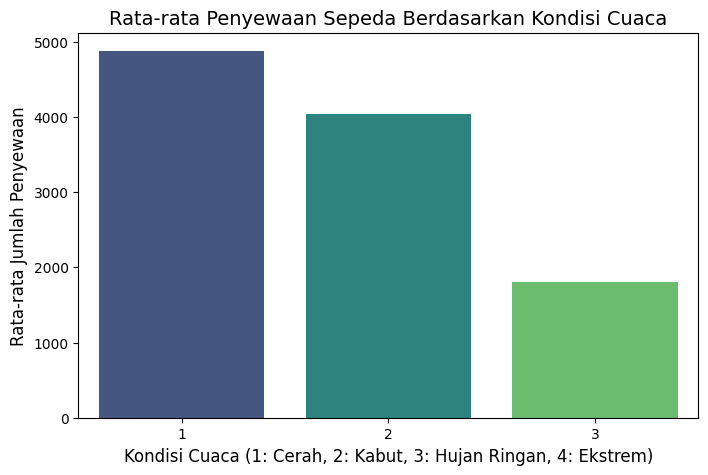

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="weathersit",
    y="cnt",
    data=weather_rentals,
    palette="viridis"
)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca", fontsize=14)
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Kabut, 3: Hujan Ringan, 4: Ekstrem)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)
plt.show()

### Pertanyaan 2:

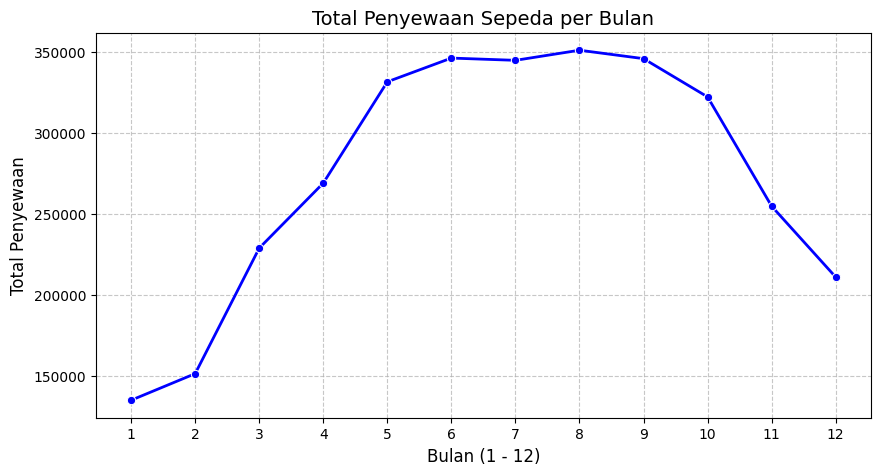

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    x="mnth",
    y="cnt",
    data=monthly_rentals,
    marker="o",
    linewidth=2,
    color="b"
)
plt.title("Total Penyewaan Sepeda per Bulan", fontsize=14)
plt.xlabel("Bulan (1 - 12)", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Conclusion

- Conclution pertanyaan 1
Kondisi cuaca sangat memengaruhi minat penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada cuaca cerah (kategori 1), dan menurun drastis saat cuaca buruk seperti hujan atau salju (kategori 3 dan 4).

- Conclution pertanyaan 2
Tren penyewaan sepeda mengalami peningkatan secara konsisten dari awal tahun dan mencapai puncaknya pada bulan ke-6 hingga ke-9. Setelah itu, jumlah penyewaan kembali menurun menjelang akhir musim gugur dan musim dingin.